# Radial BLDC vs axial-flux: a robot-actuator design case study

This notebook drives `robotactuatormdo` end to end to compare a **radial BLDC** actuator against
an **axial-flux PM** actuator for a quadruped-knee-scale joint. The radial machine is sized by the
package's first-order radial model; the axial machine is evaluated by
[`axfluxmdo`](https://github.com/jman4162/axfluxmdo) and bridged through `AxFluxMDOAdapter` so both
present the same `MotorModel` interface.

**Scope and honesty.** Every model here is first-order, intended for architecture screening rather
than detailed design. Absolute torque densities read low versus commercial datasheets because both
first-order sizing models are conservative; the value is in the *relative* comparison, the
geometric reasoning, and the workflow. Literature figures used for context are cited inline:
axial-flux PM motors reach roughly 15–25 N·m/kg peak at 92–95% efficiency
([IEEE Spectrum / YASA](https://spectrum.ieee.org/axial-flux-motor-yasa);
[PatSnap synthesis](https://www.patsnap.com/resources/blog/articles/cut-humanoid-robot-joint-actuator-weight-by-40-50/)),
and radial QDD actuators such as the MIT Cheetah HT-04 (720 g, 35 N·m peak with a 6:1 reducer)
anchor the radial side ([RobotDigg](https://www.robotdigg.com/product/1667/)).

In [1]:
import numpy as np

import _case_study_lib as lib
from robotactuatormdo import (
    Actuator, DutyCycle, FactoryCandidate, JointRequirement, Objective,
    compare_topologies, evaluate_over_duty_cycle, integrate_thermal, radial_pm_network,
    score_candidate,
)
from robotactuatormdo.actuators.gearbox import planetary
from robotactuatormdo.geometry import shear_stress as ss
from robotactuatormdo.studies.pareto import grid, pareto_front

lib.use_style()
import matplotlib.pyplot as plt

bldc, bldc_params = lib.build_radial_bldc(bus_voltage_v=48.0)
axial, used_real = lib.build_axial(bus_voltage_v=48.0)
print(f"Axial model source: {'real axfluxmdo' if used_real else 'literature scalars (fallback)'}")

Axial model source: real axfluxmdo


## 1. Joint requirement
A quadruped-knee-scale joint at a 48 V bus. The duty cycle is a stance push (high torque, low
speed) followed by a swing (low torque, higher speed).

In [2]:
duty = DutyCycle.from_segments([(0.5, 16.0, 6.0), (0.5, 4.0, 18.0)])
req = JointRequirement(
    peak_torque_nm=20.0, continuous_rms_torque_nm=7.0, max_speed_rad_s=18.0,
    bus_voltage_v=48.0, max_phase_current_a_rms=60.0, envelope_outer_diameter_m=0.12,
    envelope_axial_length_m=0.06, max_mass_kg=5.0, ambient_temp_c=30.0, duty_cycle=duty,
)
print(f"peak {req.peak_torque_nm} N·m, continuous {req.continuous_rms_torque_nm} N·m, "
      f"max speed {req.max_speed_rad_s} rad/s")

peak 20.0 N·m, continuous 7.0 N·m, max speed 18.0 rad/s


## 2. Geometric fair comparison (air-gap shear stress)
At equal tangential shear stress, radial torque scales with `r_g²·L` and axial torque with
`r_o³ − r_i³`. For a fixed outer diameter and a short axial envelope, the axial annulus converts
more of the available radius into torque. This is the package's own axial-aware physics and does
not depend on either motor model.

At 120 mm OD: radial 20.4 N·m, axial 10.6 N·m (0.5x).


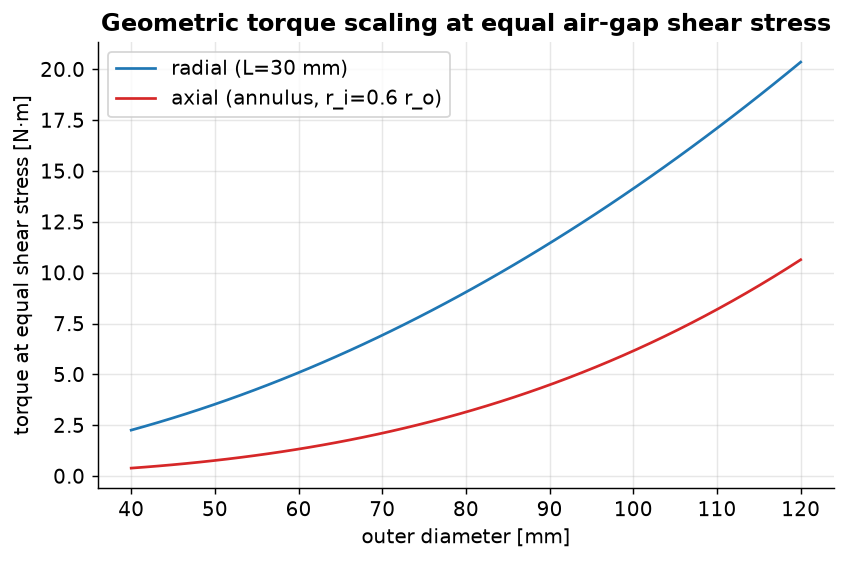

In [3]:
sigma = 30_000.0  # Pa, a representative first-order air-gap shear stress
r_o = 0.060
diam = np.linspace(0.04, 0.12, 50)            # outer diameter sweep [m]
r_out = diam / 2
stack = 0.030                                  # radial stack length [m]
t_radial = np.array([ss.torque_radial(sigma, r, stack) for r in r_out])
t_axial = np.array([ss.torque_axial(sigma, r, 0.6 * r) for r in r_out])   # r_i = 0.6 r_o

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(diam * 1e3, t_radial, color=lib.RADIAL_COLOR, label=f"radial (L={stack*1e3:.0f} mm)")
ax.plot(diam * 1e3, t_axial, color=lib.AXIAL_COLOR, label="axial (annulus, r_i=0.6 r_o)")
ax.set_xlabel("outer diameter [mm]")
ax.set_ylabel("torque at equal shear stress [N·m]")
ax.set_title("Geometric torque scaling at equal air-gap shear stress")
ax.legend()
lib.save_fig(fig, "fig1_shear_stress.png")
print(f"At 120 mm OD: radial {t_radial[-1]:.1f} N·m, axial {t_axial[-1]:.1f} N·m "
      f"({t_axial[-1] / t_radial[-1]:.1f}x).")

**Takeaway.** The axial annulus's `r³` scaling overtakes the radial `r²·L` law as diameter grows,
which is why axial topologies suit large-diameter, short-axial-length "pancake" joints.

## 3. Motor-only comparison and torque–speed envelopes

radial BLDC : mass  3449 g | peak 11.8 N·m | torque density 3.4 N·m/kg | top speed 183 rad/s
axial flux  : mass  1487 g | peak  7.5 N·m | torque density 5.0 N·m/kg | top speed 250 rad/s


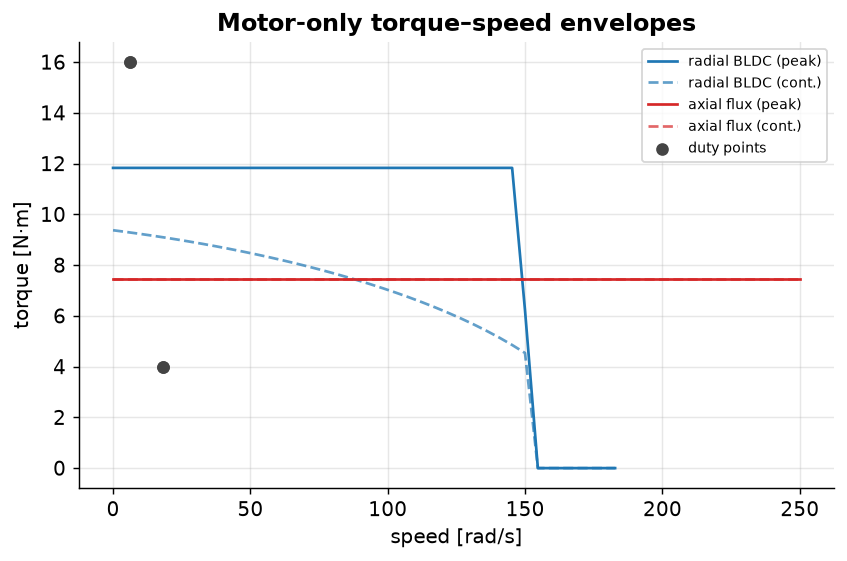

In [4]:
def motor_summary(name, m):
    env = m.torque_speed_envelope()
    mass = m.mass_properties().total_mass_kg
    peak = float(np.max(env.peak_torque_nm))
    return dict(name=name, mass=mass, peak=peak, td=peak / mass,
                top_speed=float(np.max(env.speed_rad_s)), env=env)

s_bldc = motor_summary("radial BLDC", bldc)
s_axial = motor_summary("axial flux", axial)
for s in (s_bldc, s_axial):
    print(f"{s['name']:12s}: mass {s['mass']*1e3:5.0f} g | peak {s['peak']:4.1f} N·m | "
          f"torque density {s['td']:.1f} N·m/kg | top speed {s['top_speed']:.0f} rad/s")

fig, ax = plt.subplots(figsize=(6.4, 4.2))
for s, c in ((s_bldc, lib.RADIAL_COLOR), (s_axial, lib.AXIAL_COLOR)):
    ax.plot(s["env"].speed_rad_s, s["env"].peak_torque_nm, color=c, label=f"{s['name']} (peak)")
    ax.plot(s["env"].speed_rad_s, s["env"].continuous_torque_nm, color=c, ls="--", alpha=0.7,
            label=f"{s['name']} (cont.)")
ax.scatter(duty.speed_rad_s, duty.torque_nm, color=lib.NEUTRAL, zorder=5, label="duty points")
ax.set_xlabel("speed [rad/s]")
ax.set_ylabel("torque [N·m]")
ax.set_title("Motor-only torque–speed envelopes")
ax.legend(fontsize=8)
lib.save_fig(fig, "fig2_envelopes.png")

## 4. Efficiency maps

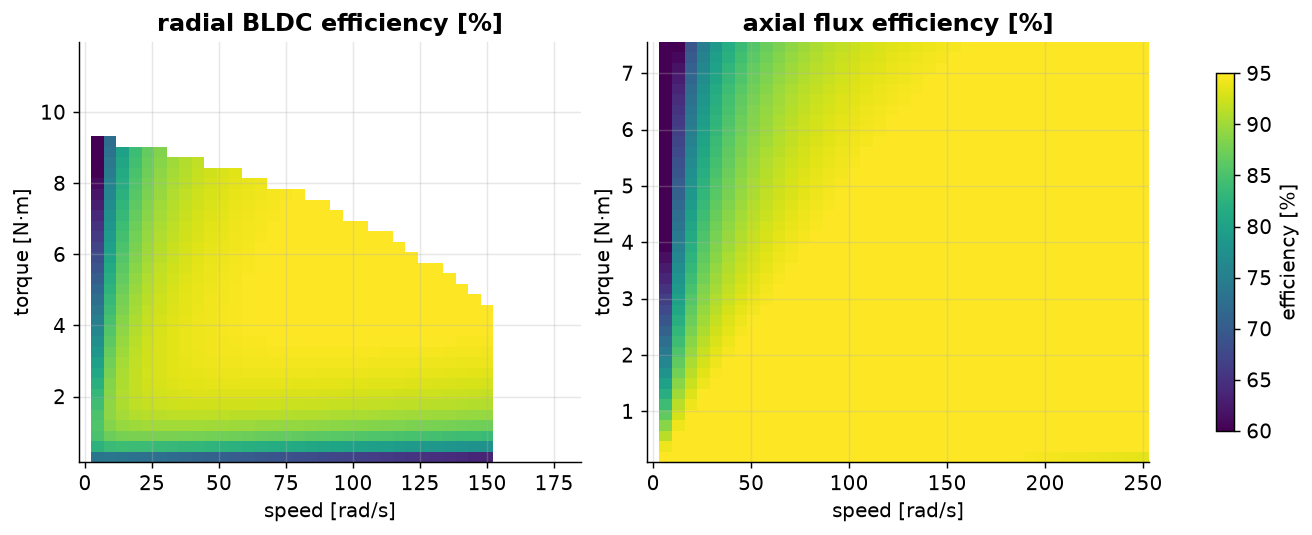

In [5]:
em_b = bldc.efficiency_map(n_speeds=40, n_torques=40)
em_a = axial.efficiency_map(n_speeds=40, n_torques=40)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.0), sharey=False)
for axp, em, title in ((axes[0], em_b, "radial BLDC"), (axes[1], em_a, "axial flux")):
    pcm = axp.pcolormesh(em.speed_rad_s, em.torque_nm, em.efficiency * 100,
                         cmap="viridis", vmin=60, vmax=95, shading="auto")
    axp.set_title(f"{title} efficiency [%]")
    axp.set_xlabel("speed [rad/s]")
    axp.set_ylabel("torque [N·m]")
fig.colorbar(pcm, ax=axes, label="efficiency [%]", shrink=0.85)
lib.save_fig(fig, "fig3_efficiency_maps.png")

## 5. Actuator level: reflected inertia and backdrive vs gear ratio
Both motors are wrapped in a planetary reduction. Gearing multiplies output torque but raises
reflected inertia as `G²`, which hurts backdrivability.

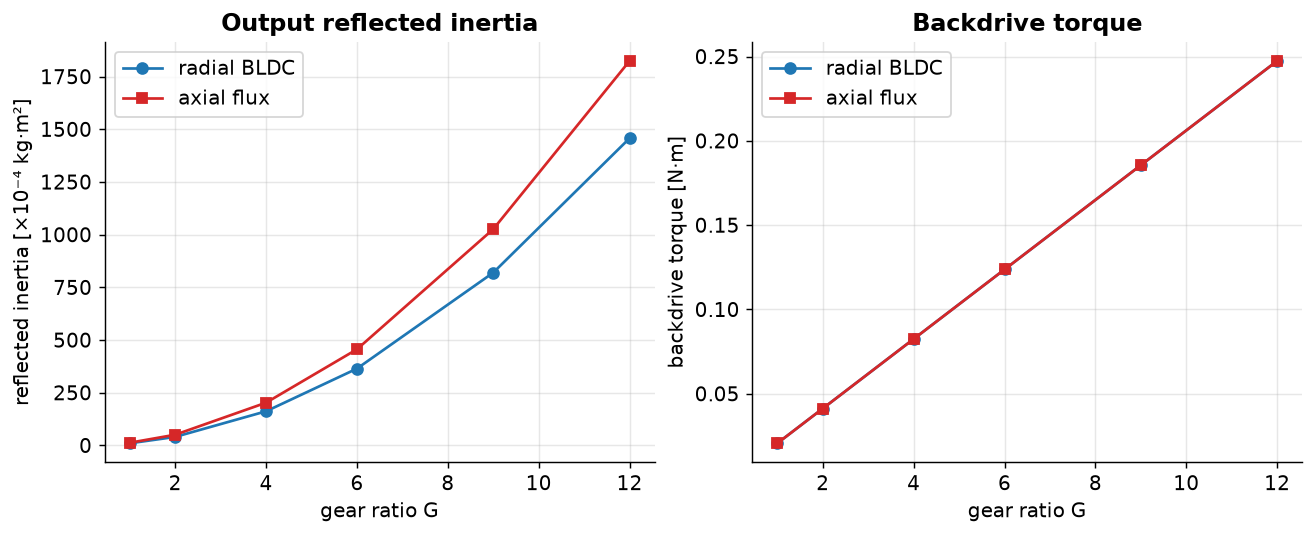

In [6]:
ratios = np.array([1, 2, 4, 6, 9, 12], dtype=float)
def actuator_curve(motor):
    refl, bd = [], []
    for g in ratios:
        a = Actuator(motor, planetary(float(g)))
        props = a.properties()
        refl.append(props.reflected_inertia_kg_m2)
        bd.append(props.backdrive_torque_nm)
    return np.array(refl), np.array(bd)

refl_b, bd_b = actuator_curve(bldc)
refl_a, bd_a = actuator_curve(axial)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.0))
axL.plot(ratios, refl_b * 1e4, "o-", color=lib.RADIAL_COLOR, label="radial BLDC")
axL.plot(ratios, refl_a * 1e4, "s-", color=lib.AXIAL_COLOR, label="axial flux")
axL.set_xlabel("gear ratio G"); axL.set_ylabel("reflected inertia [×10⁻⁴ kg·m²]")
axL.set_title("Output reflected inertia"); axL.legend()
axR.plot(ratios, bd_b, "o-", color=lib.RADIAL_COLOR, label="radial BLDC")
axR.plot(ratios, bd_a, "s-", color=lib.AXIAL_COLOR, label="axial flux")
axR.set_xlabel("gear ratio G"); axR.set_ylabel("backdrive torque [N·m]")
axR.set_title("Backdrive torque"); axR.legend()
lib.save_fig(fig, "fig4_actuator.png")

## 6. Mission over the duty cycle
Each motor is geared (6:1) to meet the joint torque, then evaluated over the duty cycle.

radial mission feasible=True, axial mission feasible=True


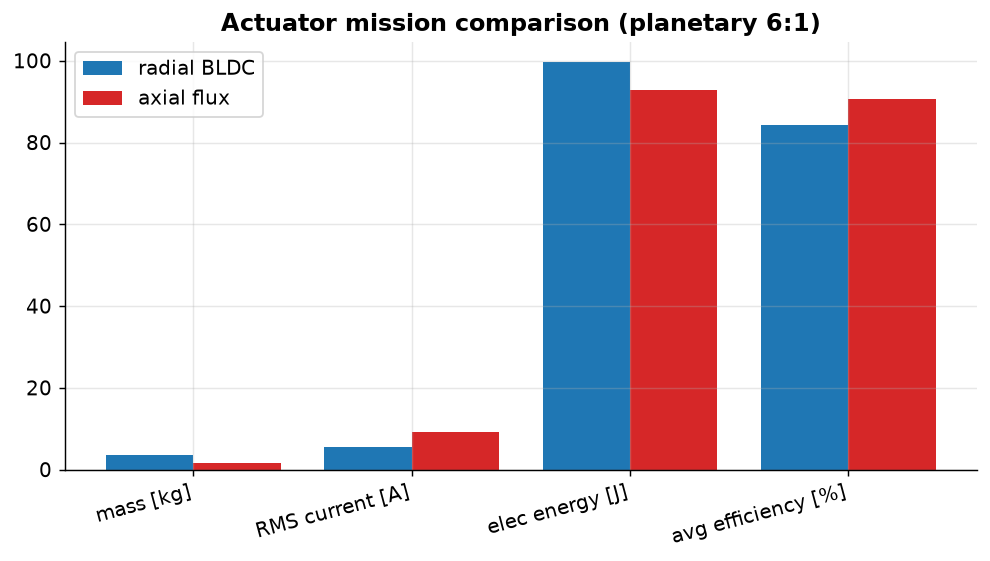

In [7]:
G = 6.0
act_b = Actuator(bldc, planetary(G))
act_a = Actuator(axial, planetary(G))
m_b = evaluate_over_duty_cycle(act_b, duty, bus_voltage_v=48.0, ambient_temp_c=30.0)
m_a = evaluate_over_duty_cycle(act_a, duty, bus_voltage_v=48.0, ambient_temp_c=30.0)
metrics = {
    "mass [kg]": (act_b.mass_properties().total_mass_kg, act_a.mass_properties().total_mass_kg),
    "RMS current [A]": (m_b.rms_phase_current_a, m_a.rms_phase_current_a),
    "elec energy [J]": (m_b.electrical_energy_j, m_a.electrical_energy_j),
    "avg efficiency [%]": (m_b.average_efficiency * 100, m_a.average_efficiency * 100),
}
labels = list(metrics)
xb = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(xb - 0.2, [metrics[k][0] for k in labels], 0.4, color=lib.RADIAL_COLOR, label="radial BLDC")
ax.bar(xb + 0.2, [metrics[k][1] for k in labels], 0.4, color=lib.AXIAL_COLOR, label="axial flux")
ax.set_xticks(xb); ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_title(f"Actuator mission comparison (planetary {G:.0f}:1)")
ax.legend()
lib.save_fig(fig, "fig5_mission.png")
print(f"radial mission feasible={m_b.all_feasible}, axial mission feasible={m_a.all_feasible}")

## 7. Thermal transient (radial BLDC)
The radial model carries a sized thermal path, so we can integrate winding temperature over a
repeated stance/idle cycle. The axial adapter does not bridge `axfluxmdo`'s thermal model, so an
axial transient is out of scope here.

peak winding temp 31.7 °C


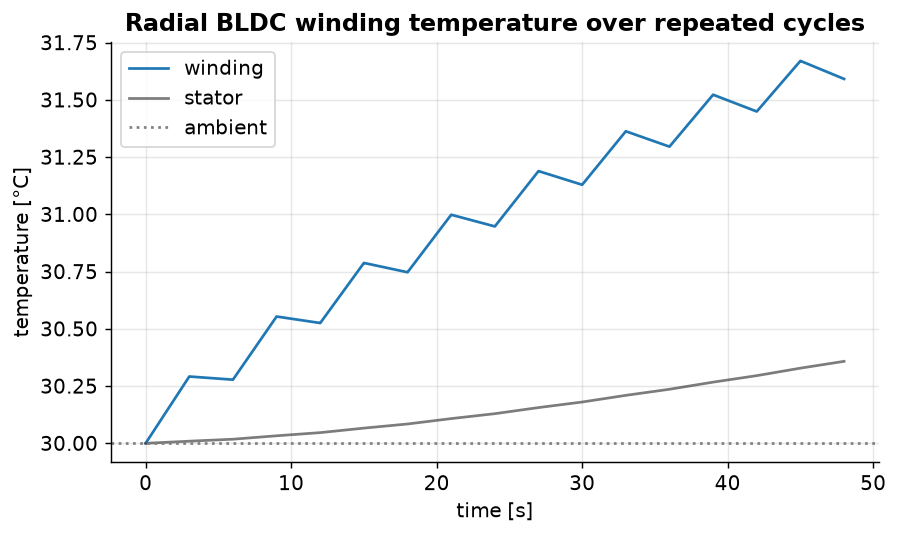

In [8]:
task = DutyCycle.from_segments([(3.0, 9.0, 6.0), (3.0, 1.0, 6.0)])
n_cycles = 8
period = task.duration_s
times = np.concatenate([task.time_s + i * period for i in range(n_cycles)])
for i in range(1, times.size):
    if times[i] <= times[i - 1]:
        times[i] = times[i - 1] + 1e-9
rep = DutyCycle(time_s=times, torque_nm=np.tile(task.torque_nm, n_cycles),
                speed_rad_s=np.tile(task.speed_rad_s, n_cycles))
net = radial_pm_network(r_winding_stator_c_w=0.15, r_stator_ambient_c_w=0.4,
                        r_magnet_ambient_c_w=2.0, ambient_c=30.0)
hist = integrate_thermal(bldc, rep, net, bus_voltage_v=48.0)
fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.plot(hist.time_s, hist.temps_of("winding"), color=lib.RADIAL_COLOR, label="winding")
ax.plot(hist.time_s, hist.temps_of("stator"), color=lib.NEUTRAL, alpha=0.7, label="stator")
ax.axhline(30.0, color="gray", ls=":", label="ambient")
ax.set_xlabel("time [s]"); ax.set_ylabel("temperature [°C]")
ax.set_title("Radial BLDC winding temperature over repeated cycles")
ax.legend()
lib.save_fig(fig, "fig6_thermal.png")
print(f"peak winding temp {hist.peak_temps_c['winding']:.1f} °C")

## 8. Pareto front: mass vs torque density
A radial geometry sweep (stack length × magnet thickness) scored on mass and torque density, with
the axial design overlaid.

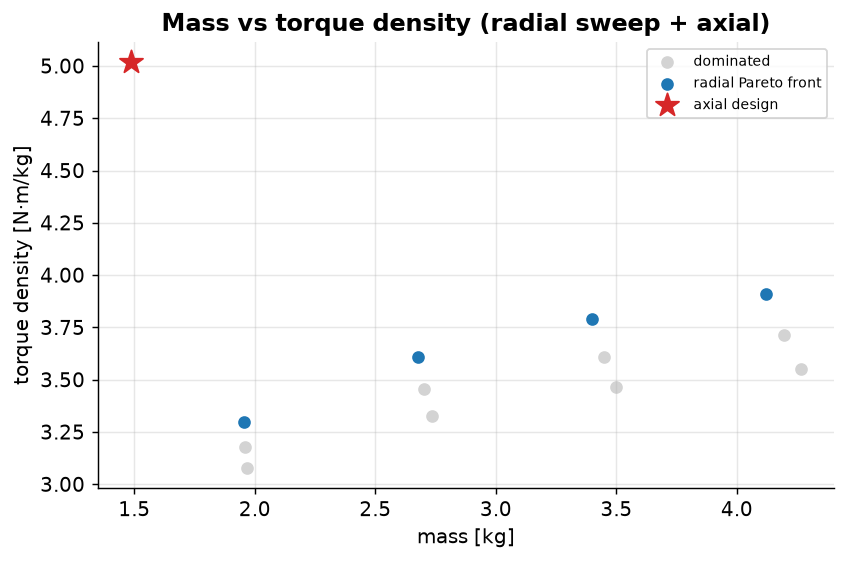

In [9]:
from dataclasses import replace

def radial_motor_from(params):
    geom = replace(lib.RADIAL_GEOM, stack_length_m=params["stack_length_m"],
                   magnet_thickness_m=params["magnet_thickness_m"])
    from robotactuatormdo import RadialPMSM, size_radial_pm
    from robotactuatormdo.materials.copper import COPPER
    from robotactuatormdo.materials.electrical_steel import M250_35A
    from robotactuatormdo.materials.magnets import NDFEB_N42
    return RadialPMSM(size_radial_pm(geom, NDFEB_N42, M250_35A, COPPER))

sweep_req = replace(req, peak_torque_nm=2.0, continuous_rms_torque_nm=0.5, max_speed_rad_s=15.0,
                    duty_cycle=DutyCycle.constant(1.5, 6.0, 1.0))
cands = grid("radial", "radial", radial_motor_from,
             {"stack_length_m": [0.02, 0.03, 0.04, 0.05],
              "magnet_thickness_m": [0.003, 0.004, 0.005]})
objs = (Objective.MASS_KG, Objective.TORQUE_DENSITY)
scores = [score_candidate(c, sweep_req, objs) for c in cands]
front = pareto_front(scores, objs)
mass_all = [s.objectives[Objective.MASS_KG] for s in scores]
td_all = [s.objectives[Objective.TORQUE_DENSITY] for s in scores]
front_set = set(front.front_indices)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.scatter([mass_all[i] for i in range(len(scores)) if i not in front_set],
           [td_all[i] for i in range(len(scores)) if i not in front_set],
           color="lightgray", label="dominated")
ax.scatter([mass_all[i] for i in front_set], [td_all[i] for i in front_set],
           color=lib.RADIAL_COLOR, zorder=5, label="radial Pareto front")
ax.scatter([s_axial["mass"]], [s_axial["td"]], color=lib.AXIAL_COLOR, marker="*", s=180, zorder=6,
           label="axial design")
ax.set_xlabel("mass [kg]"); ax.set_ylabel("torque density [N·m/kg]")
ax.set_title("Mass vs torque density (radial sweep + axial)")
ax.legend(fontsize=8)
lib.save_fig(fig, "fig7_pareto.png")

## 9. Architecture comparison: per-axis winners
Four architecture classes scored against the joint requirement. The result is a per-axis winner
map across the feasible classes.

feasible classes: ('radial_bldc_qdd', 'axial_qdd')
  winner[mass_kg]: axial_qdd
  winner[peak_torque_nm]: radial_bldc_qdd
  winner[reflected_inertia_kg_m2]: radial_bldc_qdd
  winner[mission_efficiency]: axial_qdd


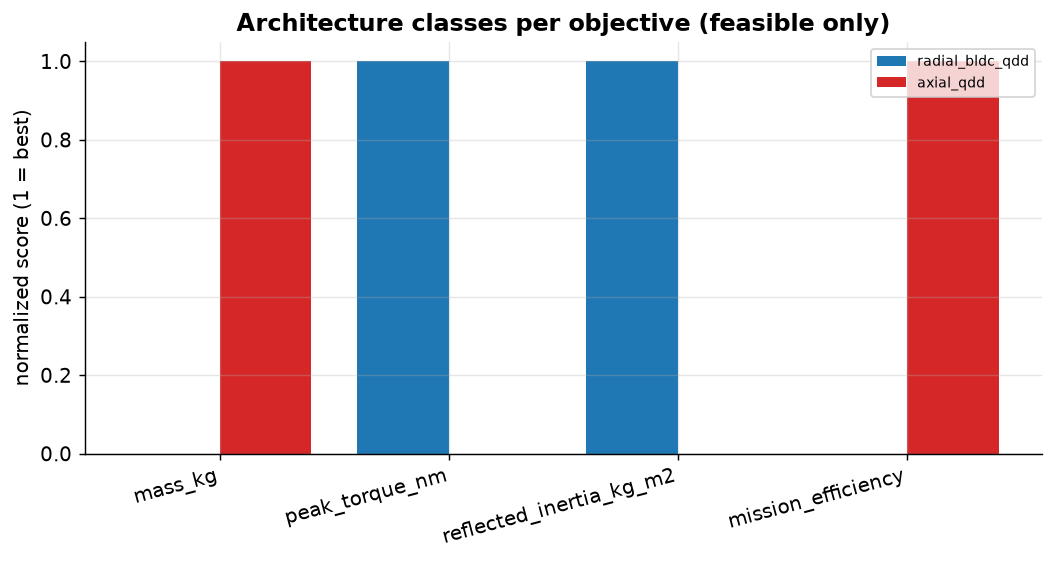

In [10]:
candidates = [
    FactoryCandidate("radial BLDC direct", "radial_bldc_direct", lambda p: lib.build_radial_bldc()[0]),
    FactoryCandidate("radial BLDC + 6:1", "radial_bldc_qdd",
                     lambda p: Actuator(lib.build_radial_bldc()[0], planetary(6.0))),
    FactoryCandidate("axial direct", "axial_direct", lambda p: lib.build_axial()[0]),
    FactoryCandidate("axial + 6:1", "axial_qdd",
                     lambda p: Actuator(lib.build_axial()[0], planetary(6.0))),
]
comp = compare_topologies(req, candidates, requirement_name="quadruped_knee")
print("feasible classes:", comp.feasible_classes)
axis_objs = [Objective.MASS_KG, Objective.PEAK_TORQUE_NM, Objective.REFLECTED_INERTIA,
             Objective.MISSION_EFFICIENCY]
fig, ax = plt.subplots(figsize=(8.0, 4.2))
classes = [s.architecture_class for s in comp.rows if s.feasible]
xc = np.arange(len(axis_objs))
width = 0.8 / max(len(classes), 1)
for k, cls in enumerate(classes):
    row = next(s for s in comp.rows if s.architecture_class == cls)
    vals = []
    for obj in axis_objs:
        col = [r.objectives[obj] for r in comp.rows if r.feasible and obj in r.objectives]
        v = row.objectives.get(obj, np.nan)
        # normalize 0..1 where 1 = best (respect sense via min/max)
        lo, hi = min(col), max(col)
        norm = 0.5 if hi == lo else (v - lo) / (hi - lo)
        from robotactuatormdo.studies.scoring import SENSE
        vals.append(1 - norm if SENSE[obj] > 0 else norm)
    ax.bar(xc + k * width, vals, width, label=cls)
ax.set_xticks(xc + width * (len(classes) - 1) / 2)
ax.set_xticklabels([o.value for o in axis_objs], rotation=15, ha="right")
ax.set_ylabel("normalized score (1 = best)")
ax.set_title("Architecture classes per objective (feasible only)")
ax.legend(fontsize=8)
lib.save_fig(fig, "fig8_compare.png")
for obj in axis_objs:
    print(f"  winner[{obj.value}]: {comp.winner_on(obj)}")

## Summary
The comparison produces a per-axis picture rather than a single winner. The shear-stress analysis
shows the geometric reason axial topologies favor large-diameter, short-axial-length joints, and
the system-level study shows where each architecture leads on mass, torque, reflected inertia, and
mission efficiency for this joint.

First-order caveats: both sizing models are analytical and conservative; `axfluxmdo` itself omits
magnetic saturation, uses a fixed magnet temperature, and a lumped thermal RC; the axial adapter
does not model an axial thermal network; and BOM cost and rotor inertia for the axial side are
first-order estimates. These models screen architectures; they do not replace detailed design or
FEA.